Sentiment Distribution:
majority_sentiment
Positive    264
Neutral     138
Negative     52
Name: count, dtype: int64
------------------------------
Total Videos: 454


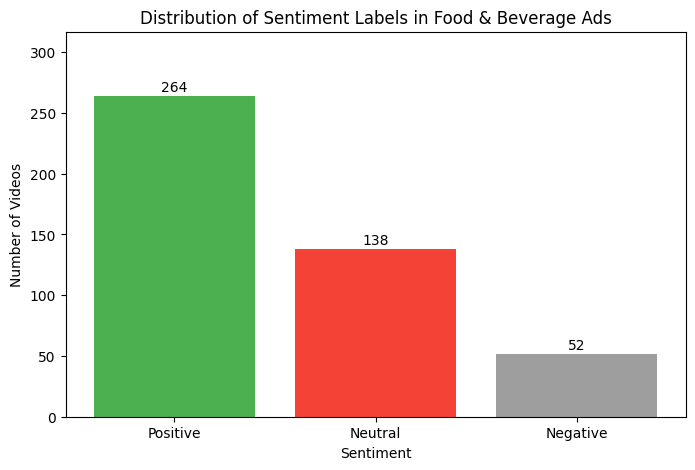

In [2]:
# CELL 1: Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the labels
labels_path = "videos_with_sentiment_labels.csv"
df = pd.read_csv(labels_path)

# 2. Count the sentiments
sentiment_counts = df['majority_sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)
print("-" * 30)
print(f"Total Videos: {len(df)}")

# 3. Plot the distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#4CAF50', '#F44336', '#9E9E9E'])

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Sentiment Labels in Food & Beverage Ads")
plt.xlabel("Sentiment")
plt.ylabel("Number of Videos")
plt.ylim(0, max(sentiment_counts.values) * 1.2) # Give headroom for labels
plt.show()

In [3]:
# CELL 2: Data Loading & Early Fusion
import numpy as np
from sklearn.preprocessing import LabelEncoder

PROJECT_PATH = "Thesis_Data"

print("Loading extracted features...")
# Load dictionaries
visual_dict = np.load(f"{PROJECT_PATH}/visual_features.npy", allow_pickle=True).item()
audio_dict = np.load(f"{PROJECT_PATH}/audio_features.npy", allow_pickle=True).item()

X_fused = []
y_labels = []

print("Aligning visual and audio modalities...")
# df is already loaded from Cell 1!
for index, row in df.iterrows():
    v_id = row['video_id']
    label = row['majority_sentiment']
    
    # Only keep videos where we successfully extracted BOTH audio and visual features
    if v_id in visual_dict and v_id in audio_dict:
        # CONCATENATE: 2048 (ResNet) + 40 (MFCC) = 2088 dimensions
        fused_vector = np.concatenate([visual_dict[v_id], audio_dict[v_id]])
        X_fused.append(fused_vector)
        y_labels.append(label)

X_fused = np.array(X_fused)
y_labels = np.array(y_labels)

print(f"Successfully fused {len(X_fused)} videos.")
print(f"Feature matrix shape: {X_fused.shape}") 

# Convert text labels ("Positive", "Negative", "Neutral") to integers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
print(f"Classes found and encoded: {le.classes_}")

Loading extracted features...
Aligning visual and audio modalities...
Successfully fused 446 videos.
Feature matrix shape: (446, 2088)
Classes found and encoded: ['Negative' 'Neutral' 'Positive']


In [4]:
# CELL 3: Stratified K-Fold CV & Neural Network Training
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

# 1. DEFINE THE NEURAL NETWORK (MLP)
class MultimodalMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MultimodalMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4), # Prevent overfitting
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# 2. CALCULATE CLASS WEIGHTS (The fix for your imbalanced data!)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)
print(f"Applying Class Weights to fix imbalance: {weights}")

# 3. SETUP 5-FOLD CROSS VALIDATION
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

input_size = X_fused.shape[1]
num_classes = len(le.classes_)

# To store all predictions across all folds for one massive final report
all_true_labels = []
all_predictions = []
fold_accuracies = []

print("\nStarting 5-Fold Cross Validation Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_fused, y_encoded)):
    print(f"\n--- FOLD {fold + 1}/{k_folds} ---")
    
    # Split data
    X_train, X_val = X_fused[train_idx], X_fused[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    # Scale features (Fit ONLY on training data to prevent cheating/leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Convert to PyTorch Tensors
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                                            torch.tensor(y_train, dtype=torch.long)), 
                              batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32), 
                                          torch.tensor(y_val, dtype=torch.long)), 
                            batch_size=32, shuffle=False)
    
    # Initialize Model, Loss (with weights!), and Optimizer
    model = MultimodalMLP(input_size, num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor) 
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Train for 20 Epochs
    epochs = 20
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Evaluate Fold
    model.eval()
    fold_preds, fold_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            fold_preds.extend(preds.numpy())
            fold_labels.extend(labels.numpy())
            
    fold_acc = accuracy_score(fold_labels, fold_preds)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold + 1} Accuracy: {fold_acc:.4f}")
    
    # Save for final overarching report
    all_true_labels.extend(fold_labels)
    all_predictions.extend(fold_preds)

print("\n" + "="*40)
print("=== FINAL MULTIMODAL RESULTS ===")
print("="*40)
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})\n")
print("Detailed Classification Report:")
# This report will show you how well it did on Positive, Negative, and Neutral individually!
print(classification_report(all_true_labels, all_predictions, target_names=le.classes_))

Applying Class Weights to fix imbalance: [2.85897436 1.09313725 0.57622739]

Starting 5-Fold Cross Validation Training...

--- FOLD 1/5 ---
Fold 1 Accuracy: 0.4778

--- FOLD 2/5 ---
Fold 2 Accuracy: 0.5618

--- FOLD 3/5 ---
Fold 3 Accuracy: 0.5056

--- FOLD 4/5 ---
Fold 4 Accuracy: 0.4831

--- FOLD 5/5 ---
Fold 5 Accuracy: 0.5506

=== FINAL MULTIMODAL RESULTS ===
Average Accuracy: 0.5158 (+/- 0.0345)

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.16      0.12      0.13        52
     Neutral       0.39      0.41      0.40       136
    Positive       0.63      0.65      0.64       258

    accuracy                           0.52       446
   macro avg       0.40      0.39      0.39       446
weighted avg       0.50      0.52      0.51       446



In [5]:
# CELL 2: Late Fusion Data Loading & Preprocessing
import numpy as np
from sklearn.preprocessing import LabelEncoder

PROJECT_PATH = "Thesis_Data"

print("Loading extracted features...")
# Load dictionaries
visual_dict = np.load(f"{PROJECT_PATH}/visual_features.npy", allow_pickle=True).item()
audio_dict = np.load(f"{PROJECT_PATH}/audio_features.npy", allow_pickle=True).item()

# Instead of one fused array, we keep them separate
X_visual = []
X_audio = []
y_labels = []

print("Aligning visual and audio modalities (Keeping them separate for Late Fusion)...")
for index, row in df.iterrows():
    v_id = row['video_id']
    label = row['majority_sentiment']
    
    # Only keep videos where we successfully extracted BOTH audio and visual features
    if v_id in visual_dict and v_id in audio_dict:
        X_visual.append(visual_dict[v_id]) # ResNet (2048)
        X_audio.append(audio_dict[v_id])   # MFCC (40)
        y_labels.append(label)

X_visual = np.array(X_visual)
X_audio = np.array(X_audio)
y_labels = np.array(y_labels)

print(f"Successfully processed {len(X_visual)} videos.")
print(f"Visual matrix shape: {X_visual.shape}") 
print(f"Audio matrix shape: {X_audio.shape}")

# Convert text labels ("Positive", "Negative", "Neutral") to integers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
print(f"Classes found and encoded: {le.classes_}")

Loading extracted features...
Aligning visual and audio modalities (Keeping them separate for Late Fusion)...
Successfully processed 446 videos.
Visual matrix shape: (446, 2048)
Audio matrix shape: (446, 40)
Classes found and encoded: ['Negative' 'Neutral' 'Positive']


In [6]:
# CELL 3: Late Fusion Network & Stratified K-Fold CV
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

# 1. DEFINE THE LATE FUSION NEURAL NETWORK
class LateFusionMLP(nn.Module):
    def __init__(self, visual_dim=2048, audio_dim=40, num_classes=3):
        super(LateFusionMLP, self).__init__()
        
        # Visual Branch
        self.visual_net = nn.Sequential(
            nn.Linear(visual_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # Audio Branch
        self.audio_net = nn.Sequential(
            nn.Linear(audio_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Final Classifier (Takes 128 visual + 32 audio = 160 features)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(160, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, visual_x, audio_x):
        v_feats = self.visual_net(visual_x)
        a_feats = self.audio_net(audio_x)
        # Concatenate intermediate features
        combined = torch.cat((v_feats, a_feats), dim=1) 
        return self.classifier(combined)

# 2. CALCULATE CLASS WEIGHTS (Fixes your imbalanced Pos/Neg/Neutral ratio)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)
print(f"Applying Class Weights to fix imbalance: {weights}")

# 3. SETUP 5-FOLD CROSS VALIDATION
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

all_true_labels = []
all_predictions = []
fold_accuracies = []

print("\nStarting 5-Fold Cross Validation Training (Late Fusion)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_visual, y_encoded)):
    print(f"\n--- FOLD {fold + 1}/{k_folds} ---")
    
    # Split data (Visual, Audio, and Labels)
    X_v_train, X_v_val = X_visual[train_idx], X_visual[val_idx]
    X_a_train, X_a_val = X_audio[train_idx], X_audio[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    # Scale features (Two separate scalers needed for Late Fusion!)
    scaler_v = StandardScaler()
    X_v_train_scaled = scaler_v.fit_transform(X_v_train)
    X_v_val_scaled = scaler_v.transform(X_v_val)
    
    scaler_a = StandardScaler()
    X_a_train_scaled = scaler_a.fit_transform(X_a_train)
    X_a_val_scaled = scaler_a.transform(X_a_val)
    
    # Convert to PyTorch Tensors (Notice the TensorDataset now takes 3 arguments)
    train_loader = DataLoader(TensorDataset(
        torch.tensor(X_v_train_scaled, dtype=torch.float32), 
        torch.tensor(X_a_train_scaled, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    ), batch_size=32, shuffle=True)
    
    val_loader = DataLoader(TensorDataset(
        torch.tensor(X_v_val_scaled, dtype=torch.float32), 
        torch.tensor(X_a_val_scaled, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ), batch_size=32, shuffle=False)
    
    # Initialize Model, Loss (with weights!), and Optimizer
    model = LateFusionMLP(visual_dim=X_visual.shape[1], audio_dim=X_audio.shape[1], num_classes=len(le.classes_))
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor) 
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Train for 20 Epochs
    epochs = 20
    for epoch in range(epochs):
        model.train()
        for inputs_v, inputs_a, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs_v, inputs_a) # Pass both inputs to the model!
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Evaluate Fold
    model.eval()
    fold_preds, fold_labels = [], []
    with torch.no_grad():
        for inputs_v, inputs_a, labels in val_loader:
            outputs = model(inputs_v, inputs_a)
            _, preds = torch.max(outputs, 1)
            fold_preds.extend(preds.numpy())
            fold_labels.extend(labels.numpy())
            
    fold_acc = accuracy_score(fold_labels, fold_preds)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold + 1} Accuracy: {fold_acc:.4f}")
    
    all_true_labels.extend(fold_labels)
    all_predictions.extend(fold_preds)

print("\n" + "="*45)
print("=== FINAL LATE FUSION MULTIMODAL RESULTS ===")
print("="*45)
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})\n")
print("Detailed Classification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=le.classes_))

Applying Class Weights to fix imbalance: [2.85897436 1.09313725 0.57622739]

Starting 5-Fold Cross Validation Training (Late Fusion)...

--- FOLD 1/5 ---
Fold 1 Accuracy: 0.5222

--- FOLD 2/5 ---
Fold 2 Accuracy: 0.5506

--- FOLD 3/5 ---
Fold 3 Accuracy: 0.4494

--- FOLD 4/5 ---
Fold 4 Accuracy: 0.5056

--- FOLD 5/5 ---
Fold 5 Accuracy: 0.5506

=== FINAL LATE FUSION MULTIMODAL RESULTS ===
Average Accuracy: 0.5157 (+/- 0.0373)

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.18      0.12      0.14        52
     Neutral       0.37      0.36      0.37       136
    Positive       0.62      0.68      0.65       258

    accuracy                           0.52       446
   macro avg       0.39      0.38      0.39       446
weighted avg       0.49      0.52      0.50       446

